<a href="https://colab.research.google.com/github/Divya7803/hotel-reservation-demo/blob/main/Fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install tensorflow scikit-learn matplotlib seaborn streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.5 MB/s eta 0:00:00


In [2]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Combine train and test
import numpy as np
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

print("Shape:", X.shape)  # (70000, 28, 28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape: (70000, 28, 28)


In [3]:
X_scaled = X / 255.0
X_scaled = np.expand_dims(X_scaled, axis=-1)  # Shape: (70000, 28, 28, 1)

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.image import resize

# Load the dataset
(X_train, _), (X_test, _) = fashion_mnist.load_data()
X = np.concatenate((X_train, X_test), axis=0)  # shape (70000, 28, 28)

# Normalize and expand dims for grayscale
X = X / 255.0
X = np.expand_dims(X, axis=-1)  # shape (70000, 28, 28, 1)

# Convert grayscale to RGB
X_rgb = np.repeat(X, 3, axis=-1)  # shape (70000, 28, 28, 3)

# Limit to smaller sample
sample_size = 5000
X_rgb_sample = X_rgb[:sample_size]

# Resize using vectorized method (FASTER alternative)
X_resized = tf.image.resize(X_rgb_sample, (96, 96)).numpy()

print("X_resized shape:", X_resized.shape)

X_resized shape: (5000, 96, 96, 3)


In [3]:
from tensorflow.keras.applications import MobileNetV2

model = MobileNetV2(include_top=False, input_shape=(96, 96, 3), pooling='avg', weights='imagenet')
features = model.predict(X_resized, batch_size=256)

print("Feature shape:", features.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step
Feature shape: (5000, 1280)


In [4]:
#Apply K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(features)

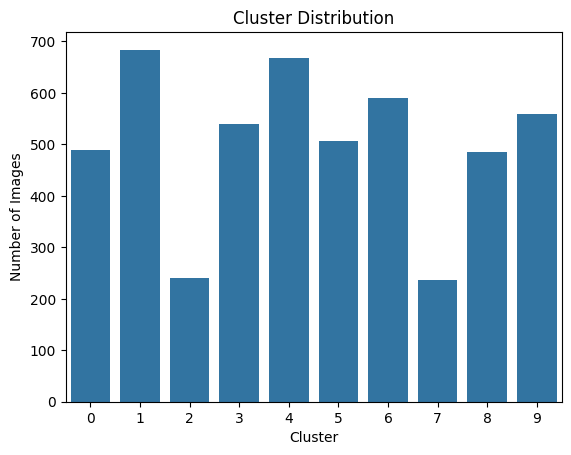

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=clusters)
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Images")
plt.show()

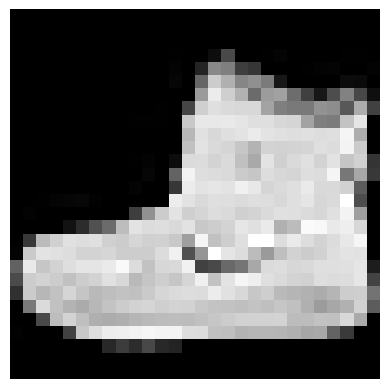

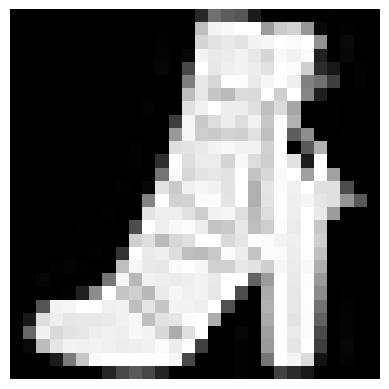

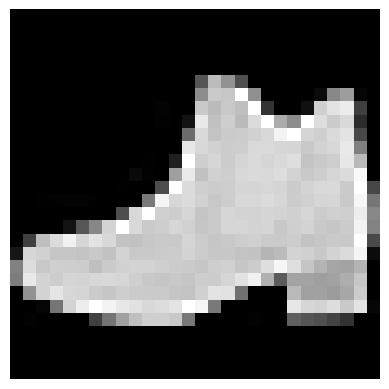

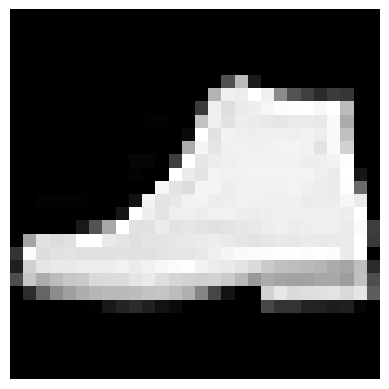

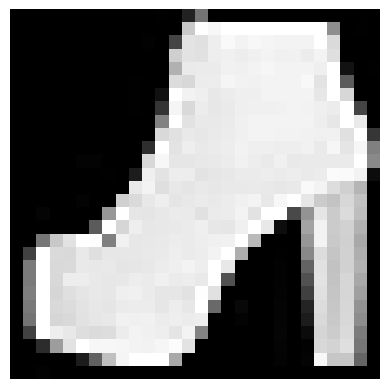

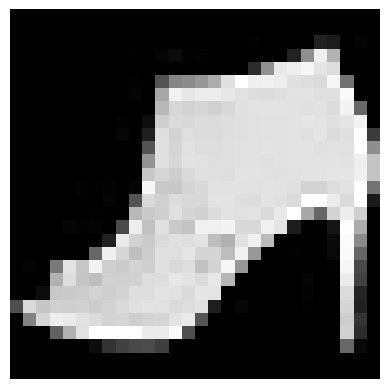

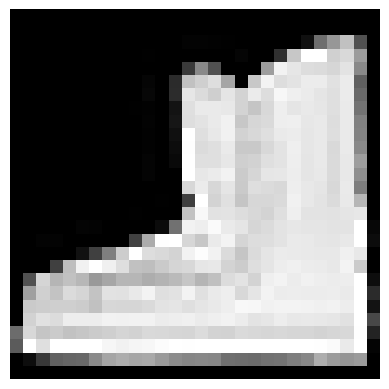

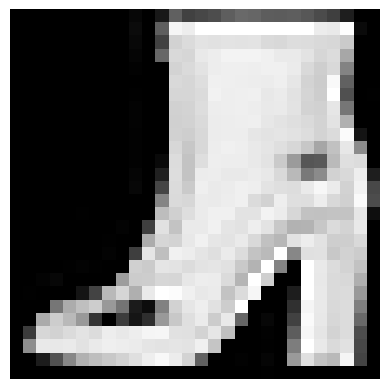

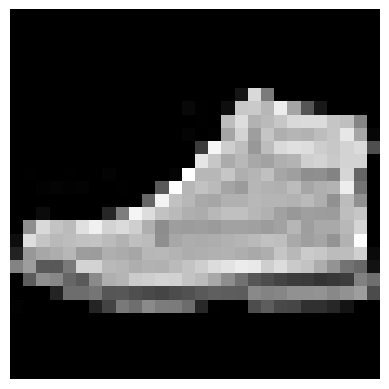

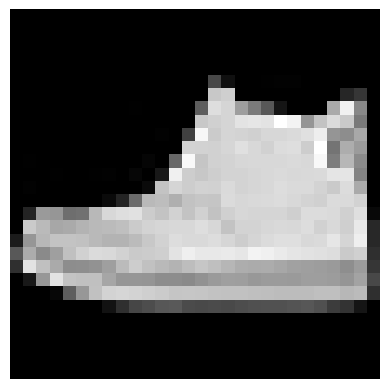

In [7]:
def plot_cluster_images(cluster_id, n=10):
    idx = np.where(clusters == cluster_id)[0][:n]
    for i in idx:
        plt.imshow(X[i].squeeze(), cmap='gray')
        plt.axis('off')
        plt.show()

plot_cluster_images(cluster_id=0)

In [9]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import fashion_mnist

# Load dataset with labels
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

# Optional: reduce to sample size
sample_size = 5000
X = X[:sample_size]
y = y[:sample_size]

# Your clusters should also be of same length
# Let's assume you already computed `clusters` from KMeans on 5000 samples

# Now create the dataframe
df_clusters = pd.DataFrame({
    'cluster': clusters,
    'true_label': y
})

# Save to CSV
df_clusters.to_csv('fashion_cluster_results.csv', index=False)